# Aircraft Engine Predictive Maintenance

## Notebook 3: Exploratory Data Analysis (EDA)

### Objectives

- Understand engine degradation
- Analyze Remaining Useful Life (RUL)
- Explore sensor behavior
- Find correlations between sensors
- Detect anomalies

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
train = pd.read_csv("../dataset/processed_train.csv")

train.head()

,engine_id,cycle,setting1,setting2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,0.0,0.00000,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191.0
1,0.0,0.00277,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190.0
2,0.0,0.00554,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189.0
3,0.0,0.00831,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188.0
4,0.0,0.01108,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187.0


In [3]:
print("Shape :", train.shape)

train.info()

Shape : (20631, 20)
<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  float64
 1   cycle      20631 non-null  float64
 2   setting1   20631 non-null  float64
 3   setting2   20631 non-null  float64
 4   sensor_2   20631 non-null  float64
 5   sensor_3   20631 non-null  float64
 6   sensor_4   20631 non-null  float64
 7   sensor_6   20631 non-null  float64
 8   sensor_7   20631 non-null  float64
 9   sensor_8   20631 non-null  float64
 10  sensor_9   20631 non-null  float64
 11  sensor_11  20631 non-null  float64
 12  sensor_12  20631 non-null  float64
 13  sensor_13  20631 non-null  float64
 14  sensor_14  20631 non-null  float64
 15  sensor_15  20631 non-null  float64
 16  sensor_17  20631 non-null  float64
 17  sensor_20  20631 non-null  float64
 18  sensor_21  20631 non-null  float64
 19  RUL        20631 non-null  float64
dt

In [4]:
train.describe()

,engine_id,cycle,setting1,setting2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.510167,0.298637,0.499490,0.501959,0.443052,0.424746,0.450435,0.980321,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127,107.807862
std,0.295229,0.190806,0.125708,0.244218,0.150618,0.133664,0.151935,0.138898,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476,68.880990
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.252525,0.141274,0.413793,0.333333,0.335843,0.331807,0.339467,1.000000,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361,51.000000
50%,0.515152,0.285319,0.500000,0.500000,0.430723,0.415522,0.435348,1.000000,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443,103.000000
75%,0.767677,0.429363,0.586207,0.750000,0.539157,0.508829,0.545324,1.000000,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582,155.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,361.000000


In [5]:
train.isnull().sum()

engine_id    0
cycle        0
setting1     0
setting2     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_17    0
sensor_20    0
sensor_21    0
RUL          0
dtype: int64

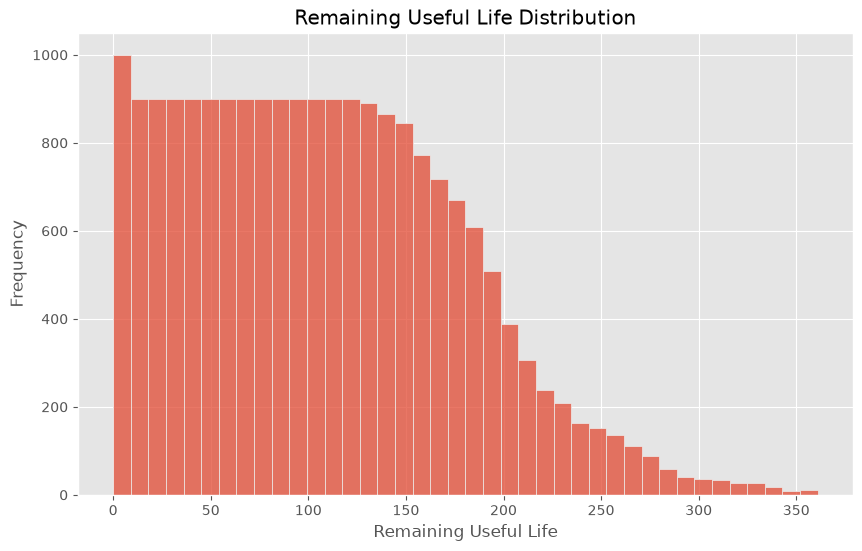

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(train["RUL"], bins=40)

plt.title("Remaining Useful Life Distribution")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Frequency")

plt.show()

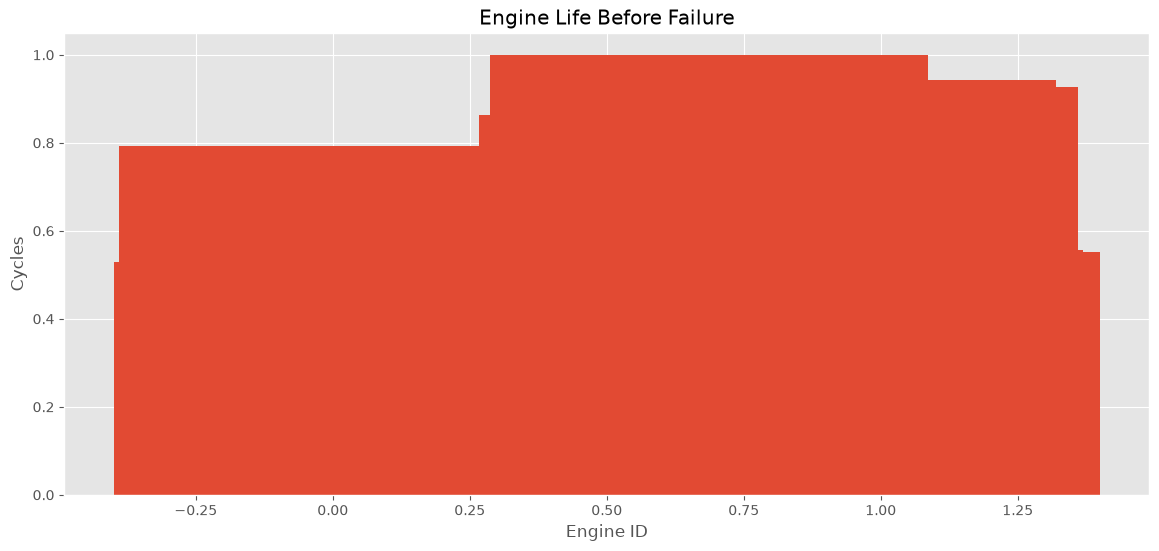

In [7]:
engine_life = train.groupby("engine_id")["cycle"].max()

plt.figure(figsize=(14,6))

plt.bar(engine_life.index, engine_life.values)

plt.title("Engine Life Before Failure")
plt.xlabel("Engine ID")
plt.ylabel("Cycles")

plt.show()

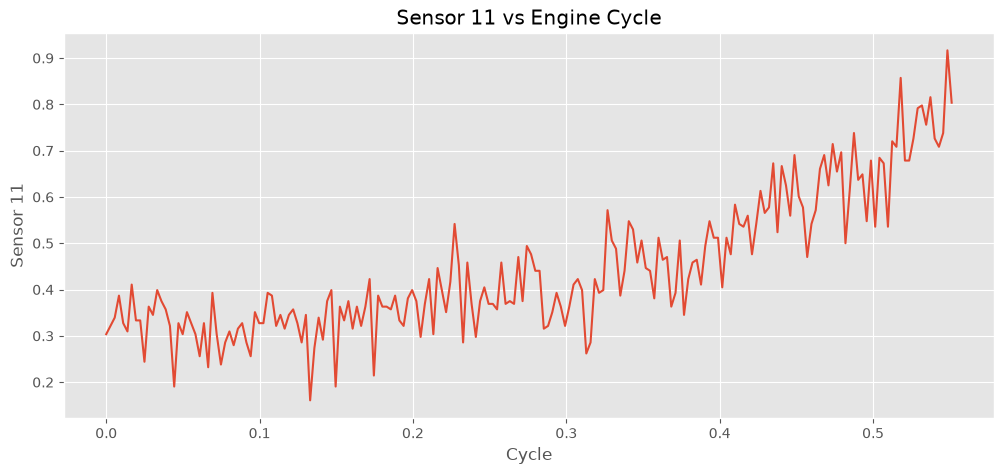

In [8]:
engine_1 = train[train["engine_id"] == 1]

plt.figure(figsize=(12,5))

plt.plot(engine_1["cycle"], engine_1["sensor_11"])

plt.title("Sensor 11 vs Engine Cycle")
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")

plt.show()

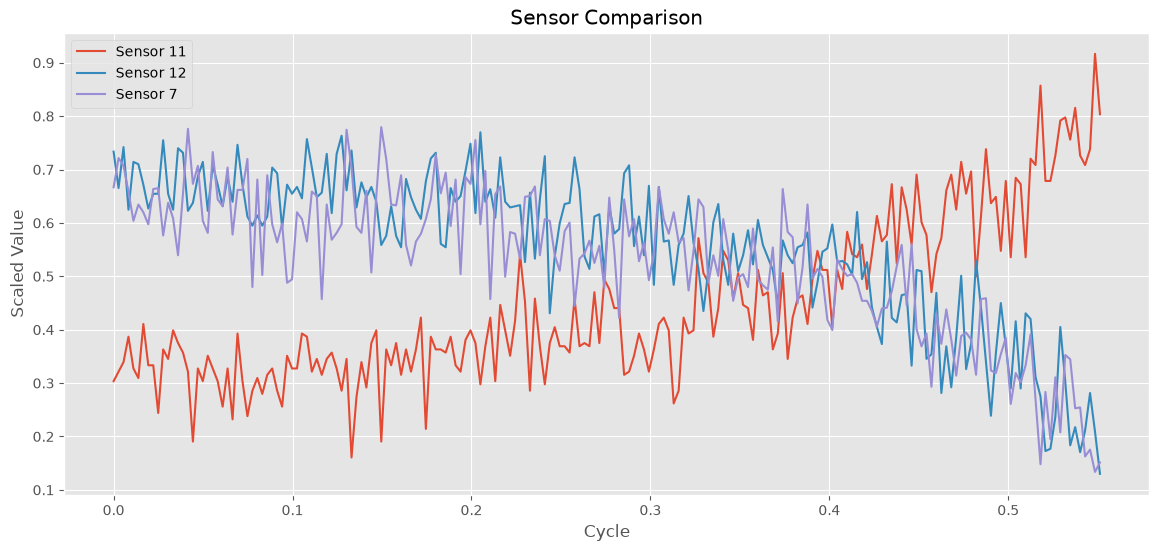

In [9]:
plt.figure(figsize=(14,6))

plt.plot(engine_1["cycle"], engine_1["sensor_11"], label="Sensor 11")
plt.plot(engine_1["cycle"], engine_1["sensor_12"], label="Sensor 12")
plt.plot(engine_1["cycle"], engine_1["sensor_7"], label="Sensor 7")

plt.legend()

plt.xlabel("Cycle")
plt.ylabel("Scaled Value")

plt.title("Sensor Comparison")

plt.show()

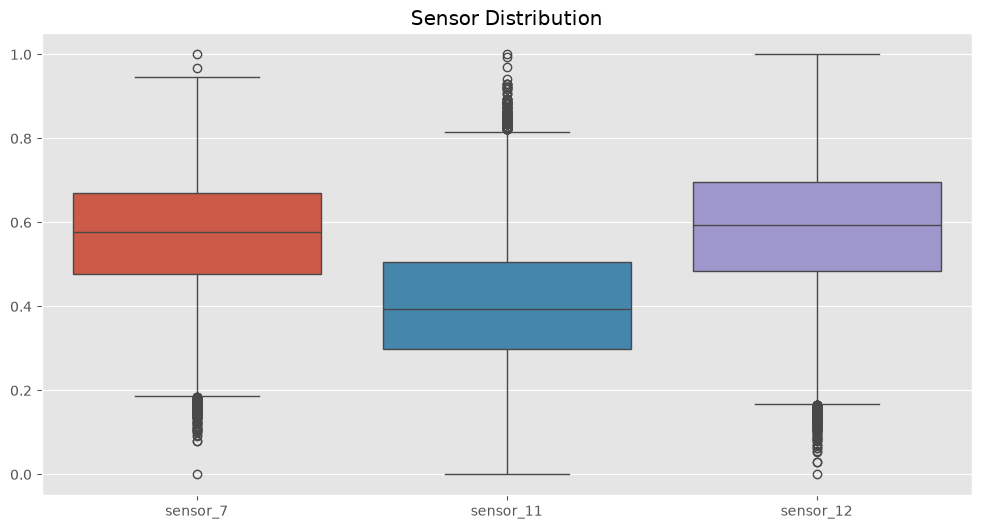

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(data=train[["sensor_7","sensor_11","sensor_12"]])

plt.title("Sensor Distribution")

plt.show()

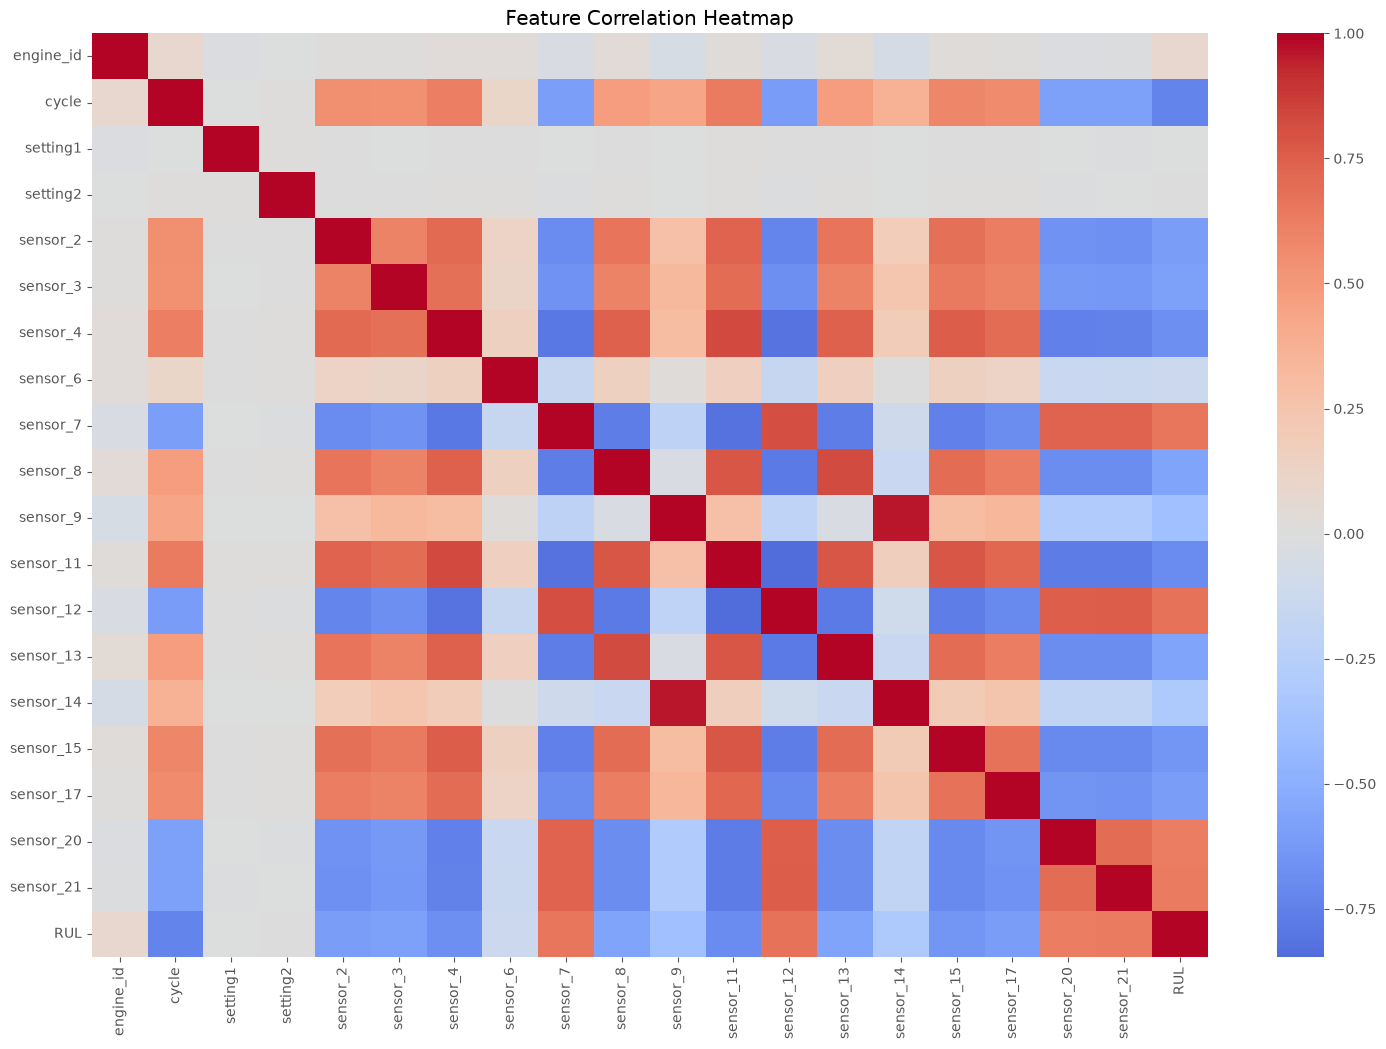

In [11]:
plt.figure(figsize=(18,12))

sns.heatmap(
    train.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [12]:
correlation = train.corr()["RUL"].sort_values(ascending=False)

correlation

RUL          1.000000
sensor_12    0.671983
sensor_7     0.657223
sensor_21    0.635662
sensor_20    0.629428
engine_id    0.078753
setting2    -0.001948
setting1    -0.003198
sensor_6    -0.128348
sensor_14   -0.306769
sensor_9    -0.390102
sensor_13   -0.562569
sensor_8    -0.563968
sensor_3    -0.584520
sensor_17   -0.606154
sensor_2    -0.606484
sensor_15   -0.642667
sensor_4    -0.678948
sensor_11   -0.696228
cycle       -0.736241
Name: RUL, dtype: float64

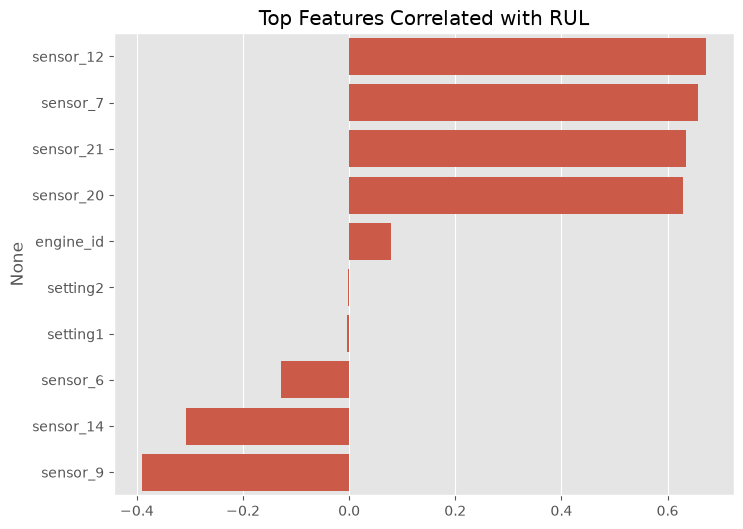

In [13]:
top_features = correlation.index[1:11]

plt.figure(figsize=(8,6))

sns.barplot(
    x=correlation[1:11].values,
    y=top_features
)

plt.title("Top Features Correlated with RUL")

plt.show()

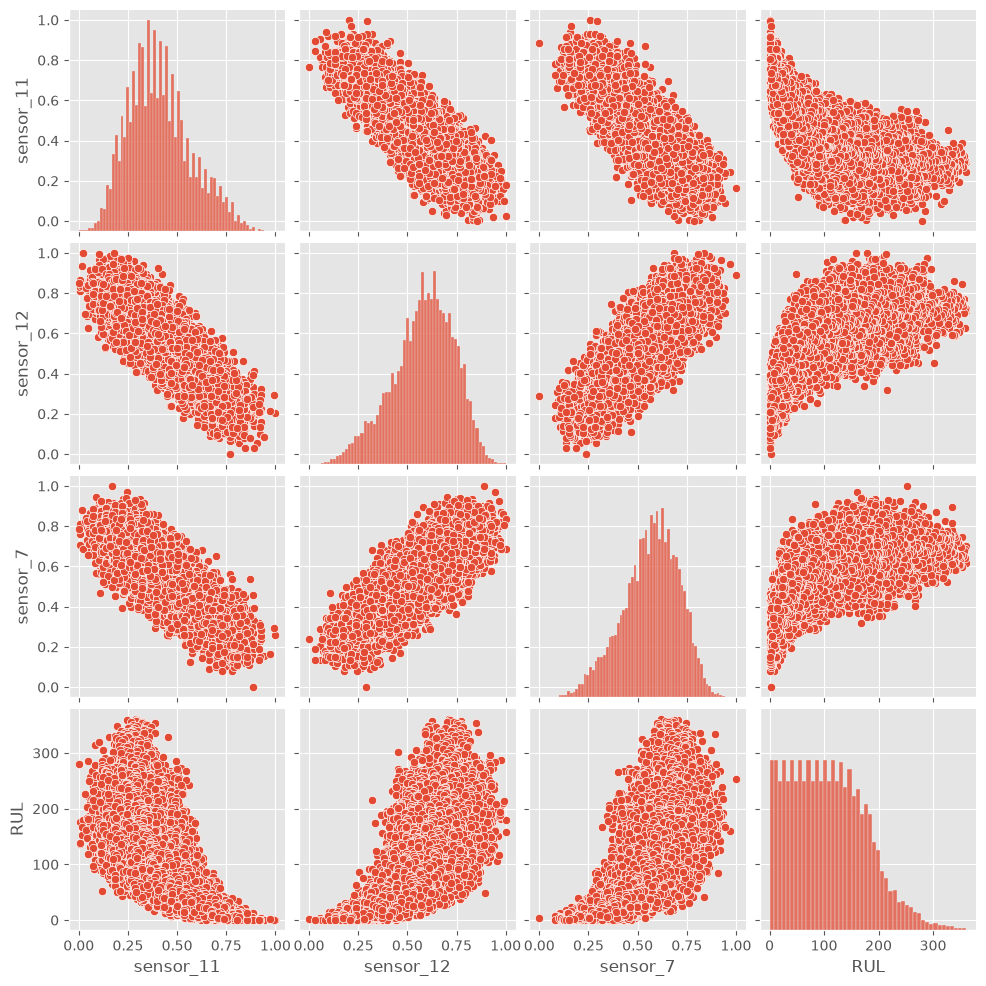

In [14]:
sns.pairplot(
    train[
        [
            "sensor_11",
            "sensor_12",
            "sensor_7",
            "RUL"
        ]
    ]
)

plt.show()

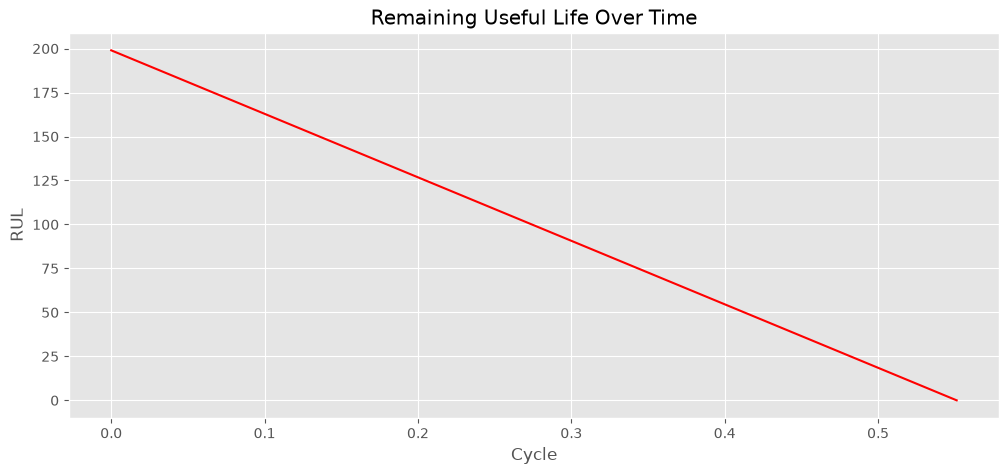

In [15]:
engine_1 = train[train["engine_id"] == 1]

plt.figure(figsize=(12,5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"],
    color="red"
)

plt.title("Remaining Useful Life Over Time")

plt.xlabel("Cycle")

plt.ylabel("RUL")

plt.show()

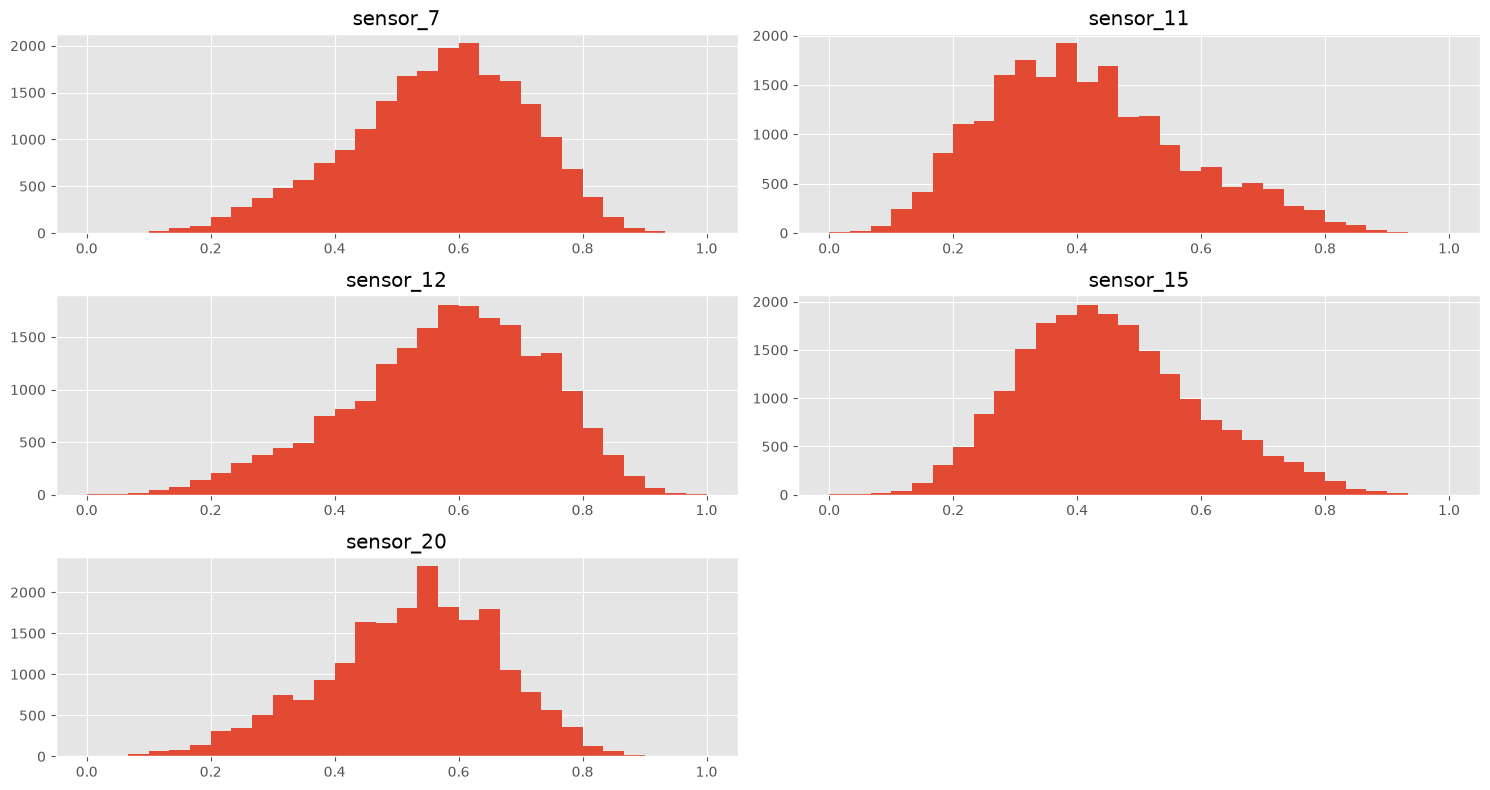

In [16]:
selected_features = [
    "sensor_7",
    "sensor_11",
    "sensor_12",
    "sensor_15",
    "sensor_20"
]

train[selected_features].hist(
    figsize=(15,8),
    bins=30
)

plt.tight_layout()

plt.show()

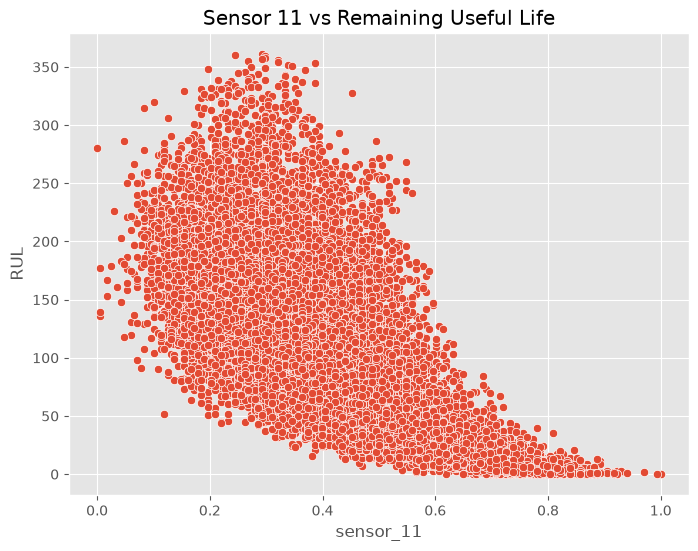

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=train["sensor_11"],
    y=train["RUL"]
)

plt.title("Sensor 11 vs Remaining Useful Life")

plt.show()

In [18]:
correlation = train.corr()["RUL"]

correlation.sort_values(ascending=False)

RUL          1.000000
sensor_12    0.671983
sensor_7     0.657223
sensor_21    0.635662
sensor_20    0.629428
engine_id    0.078753
setting2    -0.001948
setting1    -0.003198
sensor_6    -0.128348
sensor_14   -0.306769
sensor_9    -0.390102
sensor_13   -0.562569
sensor_8    -0.563968
sensor_3    -0.584520
sensor_17   -0.606154
sensor_2    -0.606484
sensor_15   -0.642667
sensor_4    -0.678948
sensor_11   -0.696228
cycle       -0.736241
Name: RUL, dtype: float64

In [19]:
correlation.sort_values(
    ascending=False
).to_csv("../outputs/feature_correlation.csv")